In [ ]:
!pip uninstall scikit-learn -y
!pip install --upgrade pip
!pip install scikit-learn

In [ ]:
!pip uninstall imbalanced-learn -y
!pip install imbalanced-learn

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



=== Training with ALL features ===

All Features
Accuracy: 0.9075
F1 Score (weighted): 0.8946

Classification Report:
                                 precision    recall  f1-score   support

          Allergy / Immunology     1.0000    1.0000    1.0000       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9957    1.0000    0.9979       233
    Cardiovascular / Pulmonary     0.7688    0.7010    0.7333       204
                  Chiropractic     0.8653    1.0000    0.9278       212
    Consult - History and Phy.     0.8056    0.5743    0.6705       202
    Cosmetic / Plastic Surgery     0.9769    1.0000    0.9883       211
                     Dentistry     0.9874    1.0000    0.9937       235
                   Dermatology     0.9953    0.9953    0.9953       211
          Diets and Nutritions     1.0000    1.0000    1.0000       221
             Discharge Summary     0.9327    0.9652    0.9487       201
          ENT -

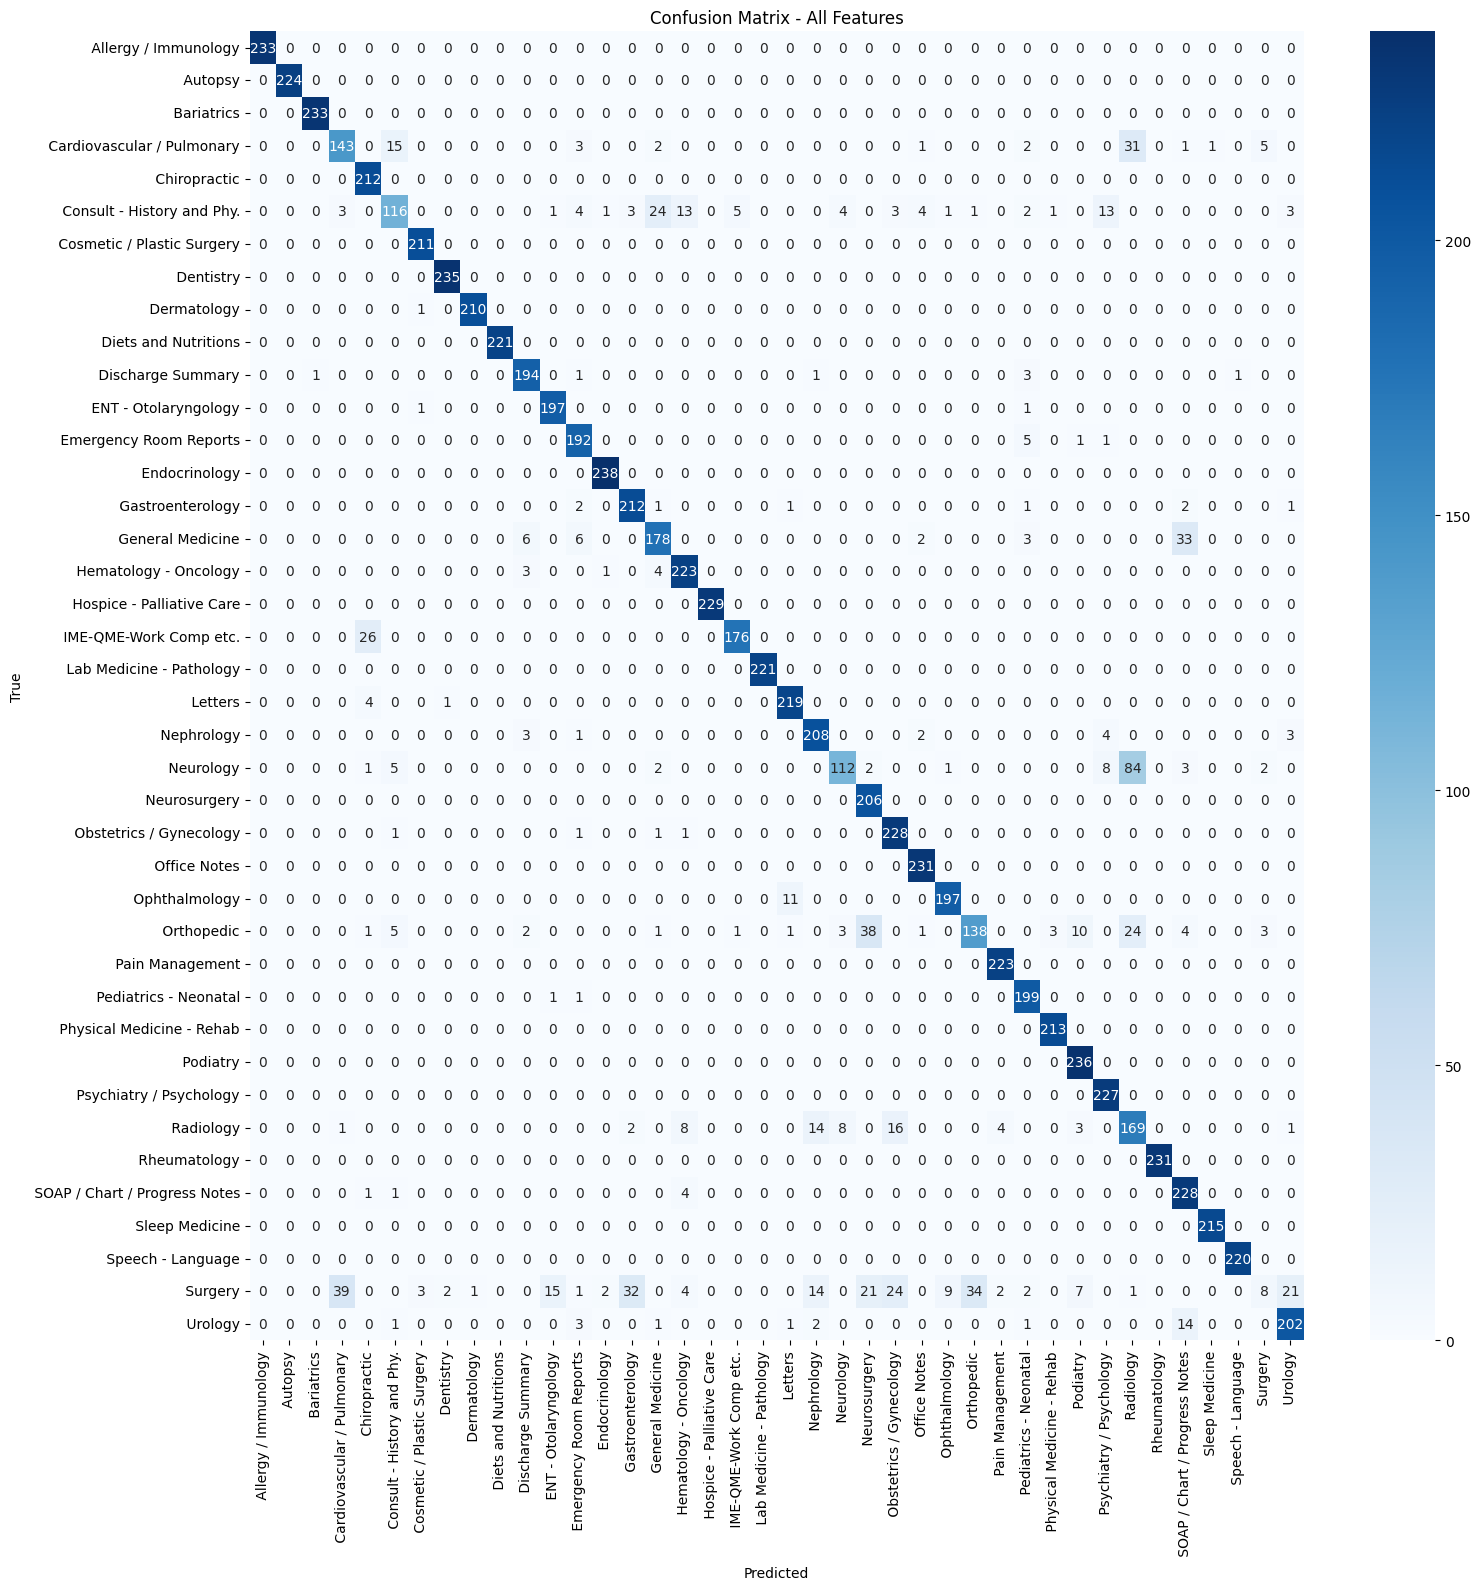


--- Ablation: excluding 'cleaned_description' ---

Without cleaned_description
Accuracy: 0.9083
F1 Score (weighted): 0.8955

Classification Report:
                                 precision    recall  f1-score   support

          Allergy / Immunology     1.0000    1.0000    1.0000       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9957    1.0000    0.9979       233
    Cardiovascular / Pulmonary     0.7807    0.7157    0.7468       204
                  Chiropractic     0.8618    1.0000    0.9258       212
    Consult - History and Phy.     0.7580    0.5891    0.6630       202
    Cosmetic / Plastic Surgery     0.9769    1.0000    0.9883       211
                     Dentistry     0.9874    1.0000    0.9937       235
                   Dermatology     0.9953    0.9953    0.9953       211
          Diets and Nutritions     1.0000    1.0000    1.0000       221
             Discharge Summary     0.9320    0.9552    0.

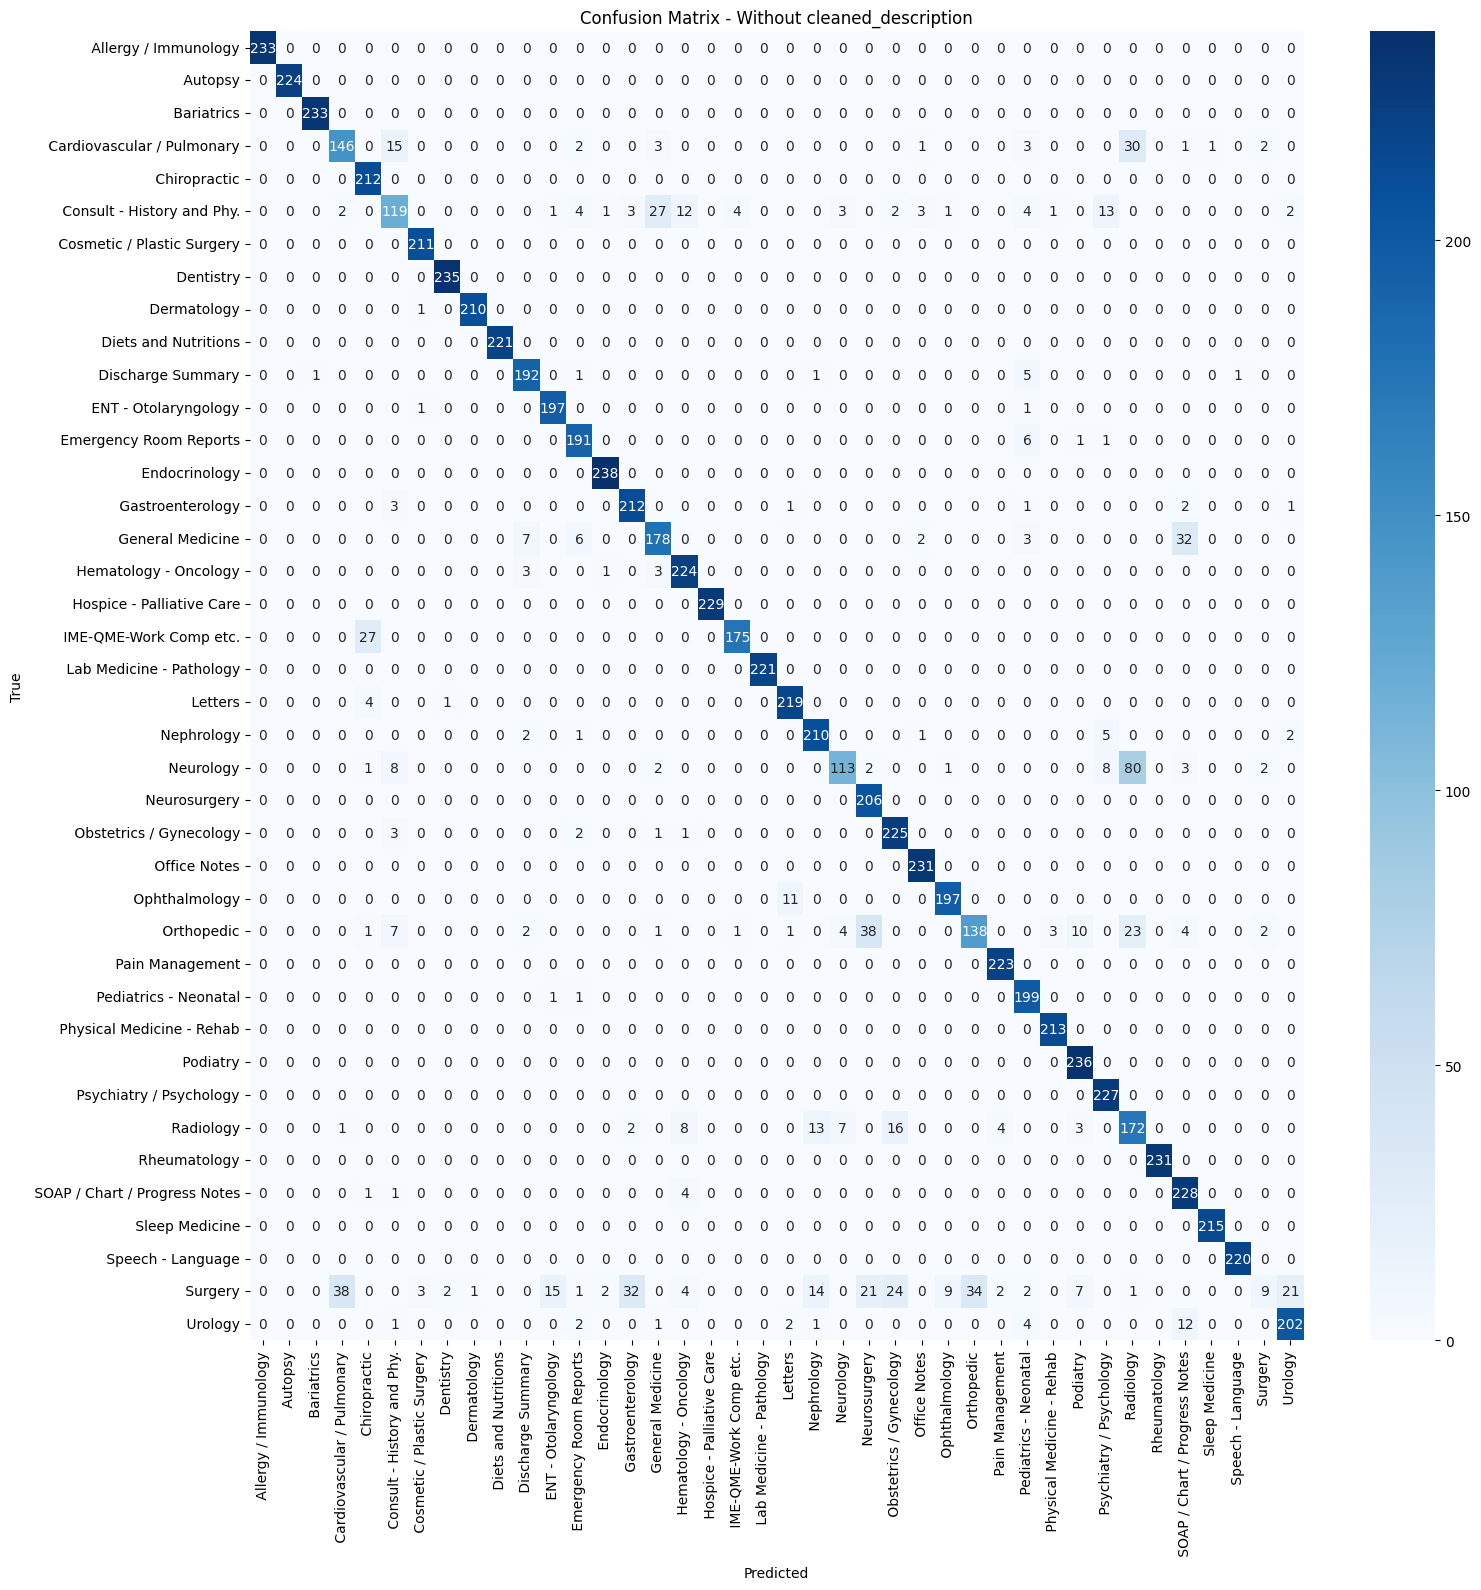


--- Ablation: excluding 'cleaned_sample_name' ---

Without cleaned_sample_name
Accuracy: 0.9079
F1 Score (weighted): 0.8950

Classification Report:
                                 precision    recall  f1-score   support

          Allergy / Immunology     1.0000    1.0000    1.0000       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     1.0000    1.0000    1.0000       233
    Cardiovascular / Pulmonary     0.7766    0.7157    0.7449       204
                  Chiropractic     0.8689    1.0000    0.9298       212
    Consult - History and Phy.     0.7905    0.5792    0.6686       202
    Cosmetic / Plastic Surgery     0.9769    1.0000    0.9883       211
                     Dentistry     0.9874    1.0000    0.9937       235
                   Dermatology     0.9953    0.9953    0.9953       211
          Diets and Nutritions     1.0000    1.0000    1.0000       221
             Discharge Summary     0.9394    0.9254    0.

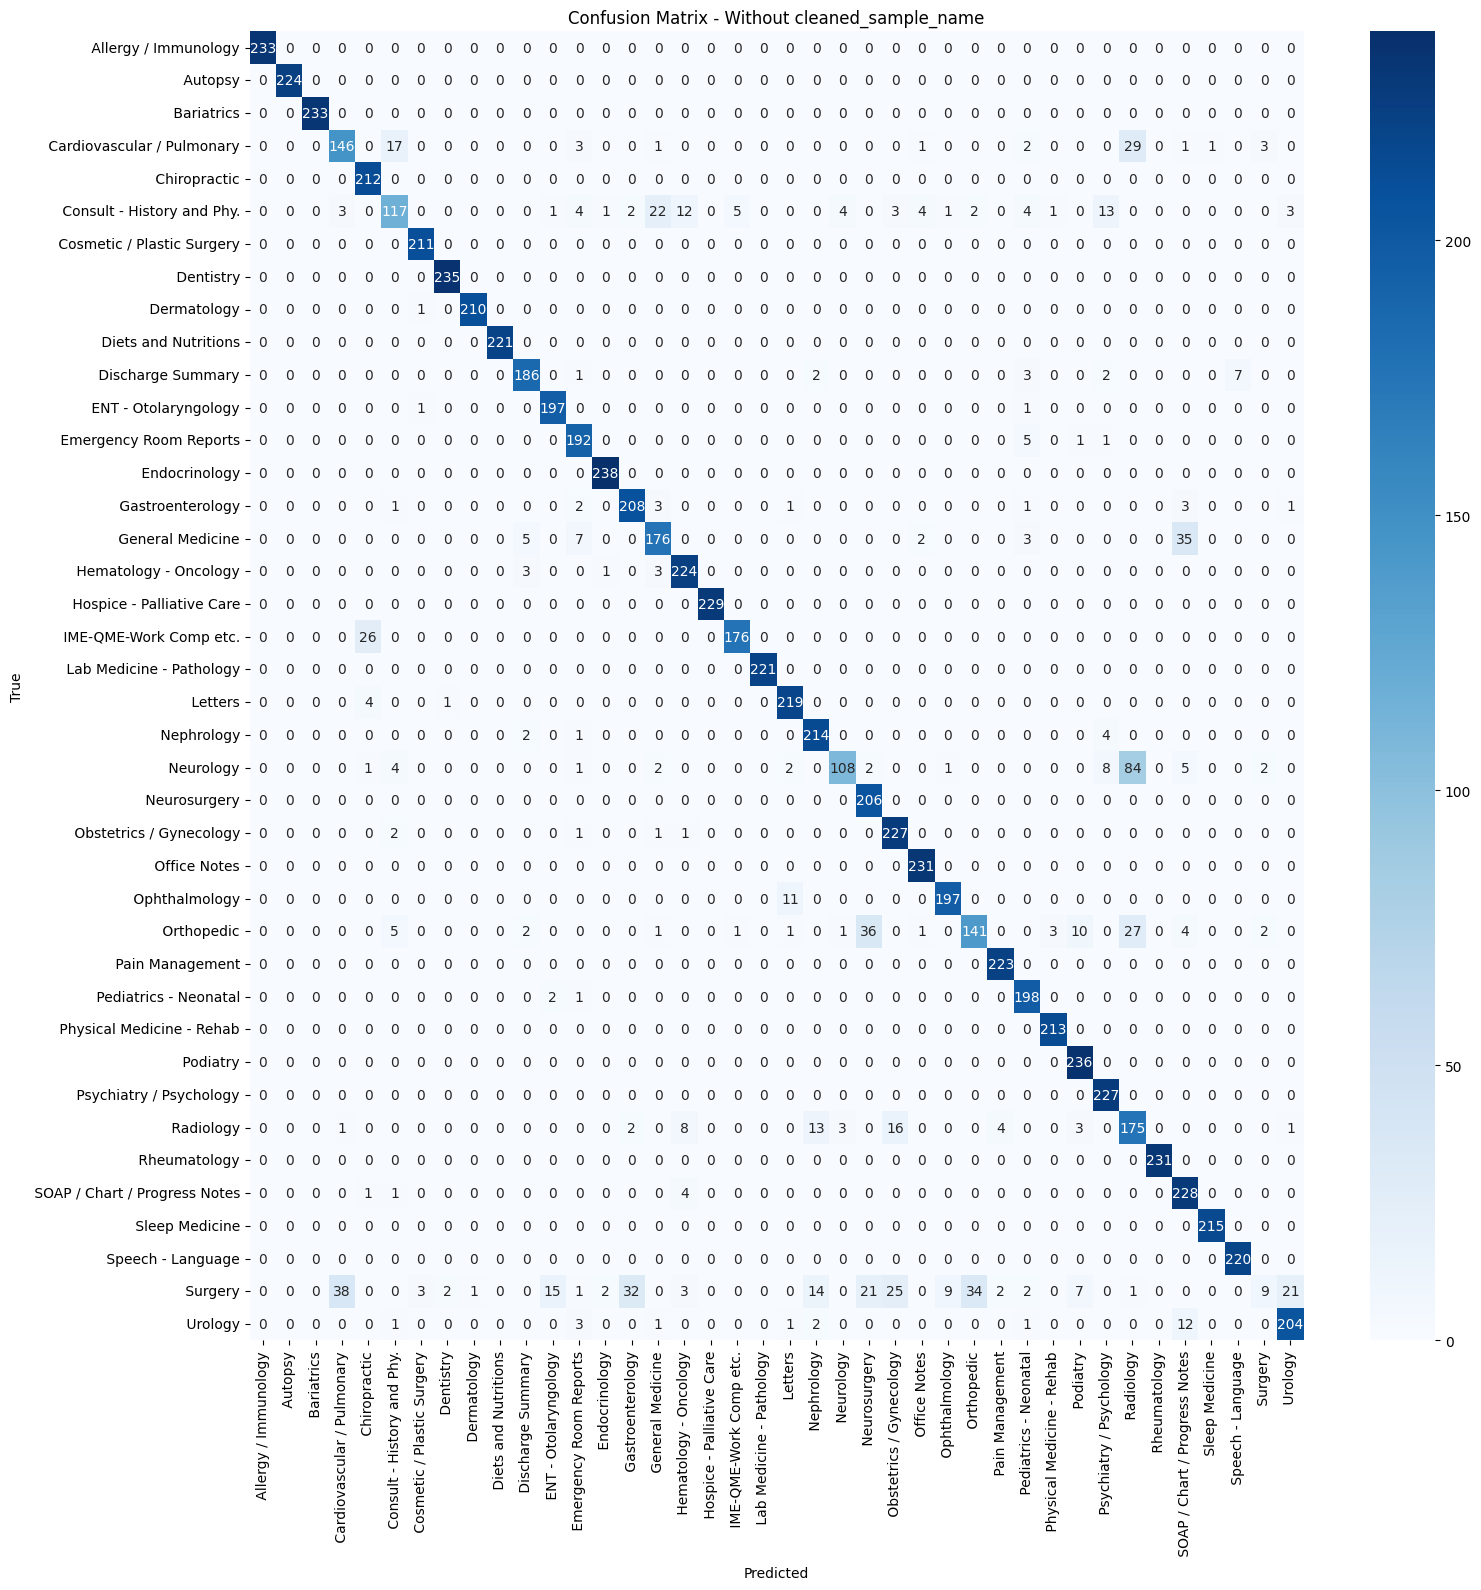


--- Ablation: excluding 'cleaned_keywords' ---

Without cleaned_keywords
Accuracy: 0.8741
F1 Score (weighted): 0.8569

Classification Report:
                                 precision    recall  f1-score   support

          Allergy / Immunology     0.9957    1.0000    0.9979       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9549    1.0000    0.9769       233
    Cardiovascular / Pulmonary     0.7308    0.5588    0.6333       204
                  Chiropractic     0.8724    1.0000    0.9319       212
    Consult - History and Phy.     0.5851    0.2723    0.3716       202
    Cosmetic / Plastic Surgery     0.9087    0.9905    0.9478       211
                     Dentistry     0.9671    1.0000    0.9833       235
                   Dermatology     0.9630    0.9858    0.9742       211
          Diets and Nutritions     0.9364    1.0000    0.9672       221
             Discharge Summary     0.8116    0.8358    0.8235  

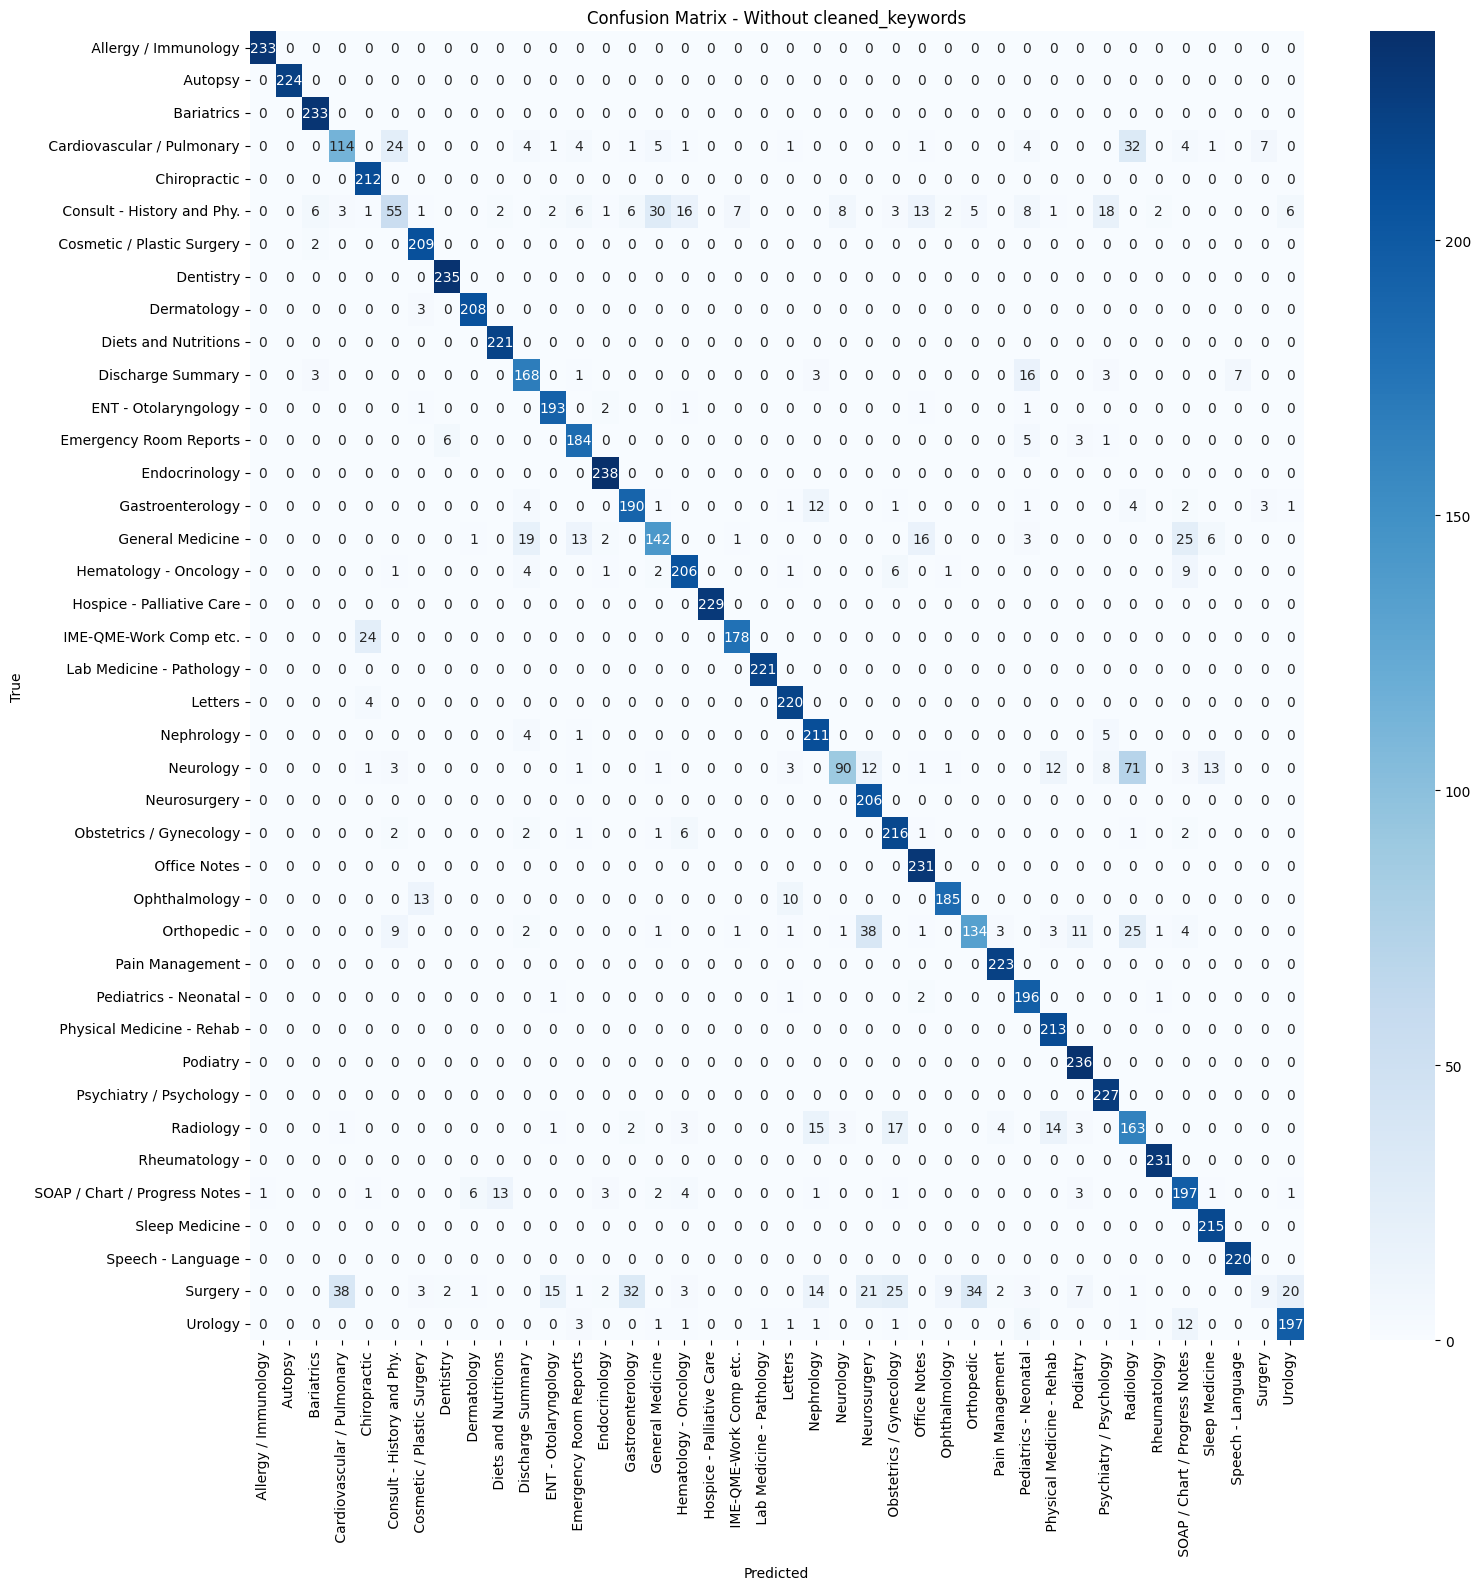


--- Ablation: excluding 'cleaned_transcription' ---

Without cleaned_transcription
Accuracy: 0.9485
F1 Score (weighted): 0.9430

Classification Report:
                                 precision    recall  f1-score   support

          Allergy / Immunology     1.0000    1.0000    1.0000       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9957    1.0000    0.9979       233
    Cardiovascular / Pulmonary     0.7592    0.9118    0.8285       204
                  Chiropractic     0.9949    0.9245    0.9584       212
    Consult - History and Phy.     0.9703    0.4851    0.6469       202
    Cosmetic / Plastic Surgery     0.9814    1.0000    0.9906       211
                     Dentistry     0.9916    1.0000    0.9958       235
                   Dermatology     0.9906    1.0000    0.9953       211
          Diets and Nutritions     1.0000    1.0000    1.0000       221
             Discharge Summary     0.9538    0.9254  

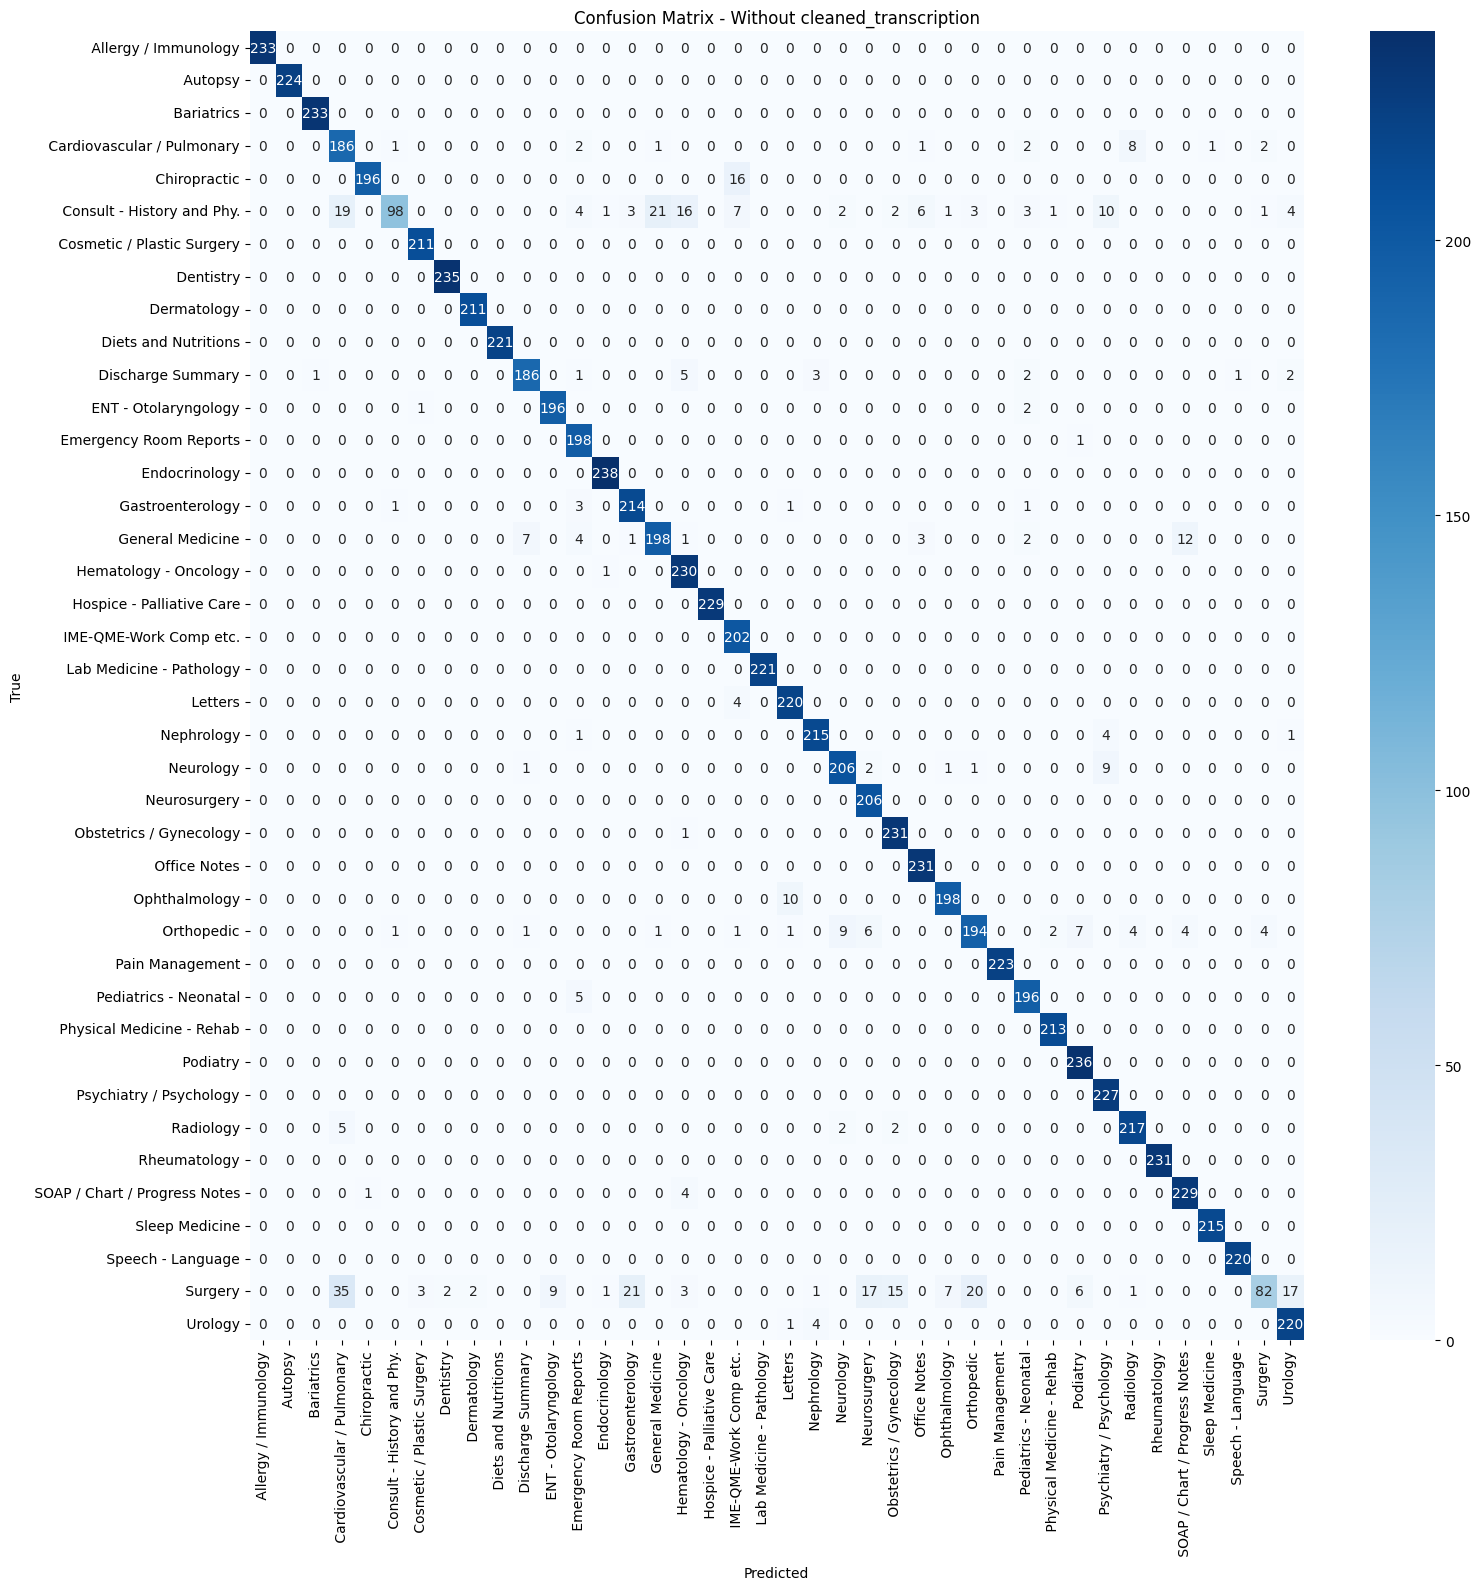


=== Final Ablation Study Results ===
                               accuracy  f1_score
Without cleaned_transcription  0.948549  0.943020
Without cleaned_description    0.908318  0.895479
Without cleaned_sample_name    0.907865  0.894965
All Features                   0.907525  0.894623
Without cleaned_keywords       0.874093  0.856912


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load dataset
data = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

# Preprocessing function
def Preprocessing(text):
    text = str(text).lower()
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub('"', '', text)
    text = re.sub(r"'s\b", "", text)
    text = re.sub("[^a-zA-Z]", " ", text)
    tokens = [w for w in text.split() if w not in stop_words]
    long_words = [i for i in tokens if len(i) >= 3]
    return " ".join(long_words).strip()

# Clean text columns
text_columns = ['description', 'sample_name', 'keywords', 'transcription']
for col in text_columns:
    data[f'cleaned_{col}'] = data[col].apply(Preprocessing)

# Define cleaned feature columns
feature_columns = ['cleaned_description', 'cleaned_sample_name', 'cleaned_keywords', 'cleaned_transcription']

# Encode target
le = LabelEncoder()
Y = le.fit_transform(data['medical_specialty'])

# Function to create TF-IDF vectors
def create_vec(texts):
    tf = TfidfVectorizer(max_features=6000, ngram_range=(1, 3), min_df=5, max_df=0.9)
    return tf.fit_transform(texts)

# Function to train and evaluate model
def train_model(model, x_train, x_val, y_train, y_val, title=""):
    model.fit(x_train, y_train)
    prediction = model.predict(x_val)
    
    acc = accuracy_score(y_val, prediction)
    f1 = f1_score(y_val, prediction, average='weighted')
    
    print(f"\n{title}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")
    
    # Classification report
    print("\nClassification Report:\n", classification_report(y_val, prediction, target_names=le.classes_, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, prediction)
    plt.figure(figsize=(17, 17))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    return acc, f1

# Dictionary to store results
ablation_results = {}

# ---------- 1. Baseline: All Features ----------
print("\n=== Training with ALL features ===")
combined_all = [' '.join(row) for row in zip(*[data[col] for col in feature_columns])]
vecs_all = create_vec(combined_all)

# Apply SMOTE
sm = SMOTE(random_state=42)
X_res_all, Y_res_all = sm.fit_resample(vecs_all, Y)

# Train/test split
x_train_all, x_val_all, y_train_all, y_val_all = train_test_split(X_res_all, Y_res_all, test_size=0.2, random_state=42)
x_train_all = x_train_all.toarray()
x_val_all = x_val_all.toarray()

# Train and evaluate
model = GaussianNB()
accuracy_all, f1_all = train_model(model, x_train_all, x_val_all, y_train_all, y_val_all, title="All Features")

ablation_results['All Features'] = {'accuracy': accuracy_all, 'f1_score': f1_all}

# ---------- 2. Ablation: Remove one feature ----------
for col_to_exclude in feature_columns:
    print(f"\n--- Ablation: excluding '{col_to_exclude}' ---")
    
    remaining_features = [data[col] for col in feature_columns if col != col_to_exclude]
    combined_text = [' '.join(row) for row in zip(*remaining_features)]
    
    vecs = create_vec(combined_text)
    X_res, Y_res = sm.fit_resample(vecs, Y)
    
    x_train, x_val, y_train, y_val = train_test_split(X_res, Y_res, test_size=0.2, random_state=42)
    x_train = x_train.toarray()
    x_val = x_val.toarray()
    
    model = GaussianNB()
    accuracy, f1 = train_model(model, x_train, x_val, y_train, y_val, title=f"Without {col_to_exclude}")
    
    ablation_results[f"Without {col_to_exclude}"] = {'accuracy': accuracy, 'f1_score': f1}

# ---------- 3. Summary of Results ----------
ablation_df = pd.DataFrame(ablation_results).T
print("\n=== Final Ablation Study Results ===")
print(ablation_df.sort_values(by='accuracy', ascending=False))